In [2]:
!pip install pynwb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.9/341.9 kB 14.4 MB/s eta 0:00:00


In [3]:
from pynwb import NWBHDF5IO

file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-train_ecephys.nwb"

io = NWBHDF5IO(file_path, 'r')
nwbfile = io.read()

print(nwbfile)

root pynwb.file.NWBFile at 0x140671268513328
Fields:
  devices: {
    electrode_probe_1 <class 'pynwb.device.Device'>,
    electrode_probe_2 <class 'pynwb.device.Device'>,
    electrode_probe_3 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    electrode_group_1 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_2 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_3 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experiment_description: Cognitive timing task in which subject attempts to reproduce interval between two cues
  experimenter: ['Hansem Sohn']
  file_create_date: [datetime.datetime(2021, 10, 29, 22, 31, 50, 351047, tzinfo=tzoffset(None, -14400))]
  identifier: 8969f328-3929-11ec-8077-43176b153428
  institution: Massachusetts Institute of Technology
  intervals: {
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  keywords: <StrDataset for HDF5 dataset "keywords": shape (4,), type "|O">


In [4]:
print(nwbfile.acquisition.keys())
print(nwbfile.processing.keys())
print(nwbfile.units)

dict_keys([])
dict_keys([])
units pynwb.misc.Units at 0x140671268213760
Fields:
  colnames: ['heldout' 'spike_times' 'obs_intervals']
  columns: (
    heldout <class 'hdmf.common.table.VectorData'>,
    spike_times_index <class 'hdmf.common.table.VectorIndex'>,
    spike_times <class 'hdmf.common.table.VectorData'>,
    obs_intervals_index <class 'hdmf.common.table.VectorIndex'>,
    obs_intervals <class 'hdmf.common.table.VectorData'>
  )
  description: data on spiking units
  id: id <class 'hdmf.common.table.ElementIdentifiers'>
  waveform_unit: volts



In [5]:
units = nwbfile.units

print(units.colnames)

('heldout', 'spike_times', 'obs_intervals')


In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
spike_times = units['spike_times'][0]

print(spike_times[:20])

[2.697 2.743 2.754 2.766 2.78  2.81  2.863 3.061 3.137 3.219 4.203 5.521
 5.63  5.88  5.952 6.315 6.333 6.347 6.738 6.795]


In [8]:
# 1. Define your bin size (e.g., 20 ms = 0.02 seconds)
bin_size = 0.02 

start_time = 0.0
end_time = np.max(spike_times) + bin_size
bins = np.arange(start_time, end_time, bin_size)

# 3. Bin the spike times
spike_counts, bin_edges = np.histogram(spike_times, bins=bins)

# 4. Optional: Convert counts to firing rate (Spikes per Second)
firing_rate = spike_counts / bin_size

print(f"First 10 spike counts: {spike_counts[:10]}")
print(f"First 10 firing rates (Hz): {firing_rate[:10]}")

First 10 spike counts: [0 0 0 0 0 0 0 0 0 0]
First 10 firing rates (Hz): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [9]:
print("Spike counts around 2.7 seconds:")
print(spike_counts[130:150])

print("\nFiring rates (Hz) around 2.7 seconds:")
print(firing_rate[130:150])

Spike counts around 2.7 seconds:
[0 0 0 0 1 0 0 2 2 0 1 0 0 1 0 0 0 0 0 0]

Firing rates (Hz) around 2.7 seconds:
[  0.   0.   0.   0.  50.   0.   0. 100. 100.   0.  50.   0.   0.  50.
   0.   0.   0.   0.   0.   0.]


In [10]:
first_active_bin = np.where(spike_counts > 0)[0][0]
print(f"First active bin index: {first_active_bin}")
print(f"Spike counts starting from there: {spike_counts[first_active_bin:first_active_bin+10]}")

First active bin index: 134
Spike counts starting from there: [1 0 0 2 2 0 1 0 0 1]


In [11]:
def bin_all_units(nwb_file, bin_size=0.02):
    units = nwb_file.units
    num_units = len(units)
    
    # 1. Find the global max time across all units to standardize the matrix size
    global_max_time = 0.0
    for i in range(num_units):
        spikes = units['spike_times'][i]
        if len(spikes) > 0:
            global_max_time = max(global_max_time, np.max(spikes))
            
    # 2. Define standard bin edges
    start_time = 0.0
    end_time = global_max_time + bin_size
    bins = np.arange(start_time, end_time, bin_size)
    num_bins = len(bins) - 1
    
    # 3. Initialize the population matrix: (Bins x Units)
    population_matrix = np.zeros((num_bins, num_units))
    
    # 4. Fill the matrix unit by unit
    for i in range(num_units):
        spikes = units['spike_times'][i]
        counts, _ = np.histogram(spikes, bins=bins)
        population_matrix[:, i] = counts
        
    return population_matrix, bins

# Bin the training data you currently have open
train_matrix, bin_edges = bin_all_units(nwbfile, bin_size=0.02)

print(f"Population matrix shape (Bins x Units): {train_matrix.shape}")
print(f"Total number of recorded neural units: {train_matrix.shape[1]}")

Population matrix shape (Bins x Units): (240467, 54)
Total number of recorded neural units: 54


In [12]:
# 1. Define the path to your test NWB file
test_file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-test_ecephys.nwb"

# 2. Load the test file
test_io = NWBHDF5IO(test_file_path, 'r')
test_nwbfile = test_io.read()

# 3. Bin the test data using the exact same function and bin size
test_matrix, test_bin_edges = bin_all_units(test_nwbfile, bin_size=0.02)

print(f"Train matrix shape: {train_matrix.shape} (Bins x Units)")
print(f"Test matrix shape:  {test_matrix.shape} (Bins x Units)")

Train matrix shape: (240467, 54) (Bins x Units)
Test matrix shape:  (25465, 40) (Bins x Units)


Highest PSD Peak Value: 0.0281
Dominant Frequency: 1.07 Hz


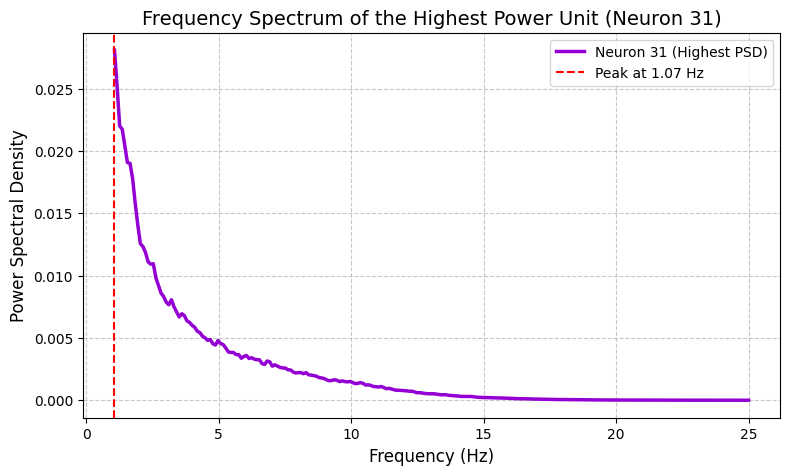

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.ndimage import gaussian_filter1d

# 1. Setup sampling parameters (50 Hz sampling rate for 20ms bins)
fs = 1 / 0.02 

# 2. Smooth and detrend the entire matrix
train_matrix_smoothed = gaussian_filter1d(train_matrix.astype(float), sigma=1, axis=0)
train_matrix_clean = train_matrix_smoothed - np.mean(train_matrix_smoothed, axis=0)

# 3. Compute Welch's PSD for ALL 54 neurons simultaneously
frequencies, psd_all = welch(train_matrix_clean, fs=fs, axis=0, nperseg=512)

# 4. Create a mask to ignore the 0 Hz baseline artifact (look from 1.0 Hz up to 25 Hz)
mask = (frequencies >= 1.0) & (frequencies <= 25.0)
f_search = frequencies[mask]
psd_search = psd_all[mask, :]  # Shape: (Filtered Frequencies x 54 Neurons)

# 5. Find the neuron with the highest absolute PSD peak in this range
peak_values_per_neuron = np.max(psd_search, axis=0)
highest_psd_neuron = np.argmax(peak_values_per_neuron)
highest_peak_value = peak_values_per_neuron[highest_psd_neuron]

# Find the exact frequency where this peak occurs
peak_freq_idx = np.argmax(psd_search[:, highest_psd_neuron])
dominant_frequency = f_search[peak_freq_idx]
print(f"Highest PSD Peak Value: {highest_peak_value:.4f}")
print(f"Dominant Frequency: {dominant_frequency:.2f} Hz")

# 6. Plot the winning neuron's spectrum to inspect it
plt.figure(figsize=(9, 5))
plt.plot(frequencies[mask], psd_all[mask, highest_psd_neuron], color='darkviolet', linewidth=2.5, label=f'Neuron {highest_psd_neuron} (Highest PSD)')
plt.axvline(x=dominant_frequency, color='red', linestyle='--', label=f'Peak at {dominant_frequency:.2f} Hz')
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Power Spectral Density', fontsize=12)
plt.title(f'Frequency Spectrum of the Highest Power Unit (Neuron {highest_psd_neuron})', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

 LOWEST PSD NEURON: Neuron 44
 Lowest PSD Peak Value: 0.000517
Dominant Frequency: 1.07 Hz


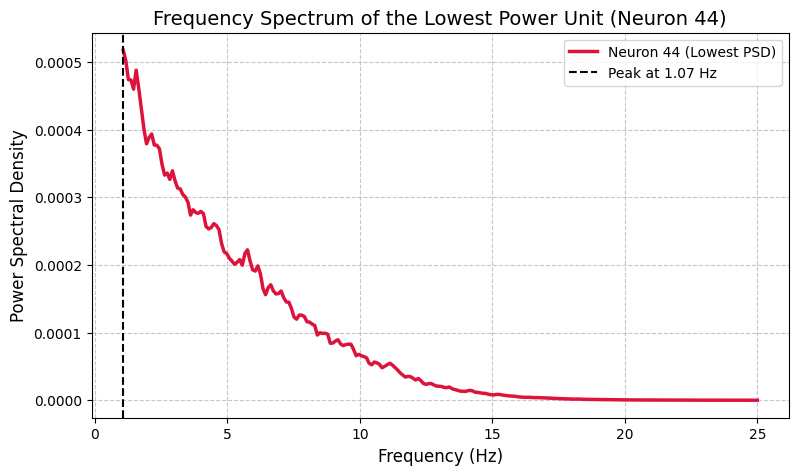

In [16]:
# Find the neuron with the lowest absolute PSD peak in this range (1.0 to 25.0 Hz)
lowest_psd_neuron = np.argmin(peak_values_per_neuron)
lowest_peak_value = peak_values_per_neuron[lowest_psd_neuron]

# Find the exact frequency where this lowest peak occurs
lowest_peak_freq_idx = np.argmax(psd_search[:, lowest_psd_neuron])
lowest_dominant_frequency = f_search[lowest_peak_freq_idx]

print(f" LOWEST PSD NEURON: Neuron {lowest_psd_neuron}")
print(f" Lowest PSD Peak Value: {lowest_peak_value:.6f}")
print(f"Dominant Frequency: {lowest_dominant_frequency:.2f} Hz")

# Optional: Plot the lowest neuron's spectrum to inspect it
plt.figure(figsize=(9, 5))
plt.plot(frequencies[mask], psd_all[mask, lowest_psd_neuron], color='crimson', linewidth=2.5, label=f'Neuron {lowest_psd_neuron} (Lowest PSD)')
plt.axvline(x=lowest_dominant_frequency, color='black', linestyle='--', label=f'Peak at {lowest_dominant_frequency:.2f} Hz')
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Power Spectral Density', fontsize=12)
plt.title(f'Frequency Spectrum of the Lowest Power Unit (Neuron {lowest_psd_neuron})', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [18]:
train_trials_df = nwbfile.intervals['trials'].to_dataframe()

print(f"Total trials in training set: {len(train_trials_df)}")
print("\nFirst 5 rows of the trials table:")
train_trials_df.head()

Total trials in training set: 1160

First 5 rows of the trials table:


,start_time,stop_time,fix_on_time,fix_time,target_on_time,ready_time,set_time,go_time,target_acq_time,reward_time,...,is_eye,theta,ts,tp,fix_time_dur,target_time_dur,iti,reward_dur,is_outlier,split
id,,,,,,,,,,,,,,,,,,,,,
0,0.5160,3.4825,0.5160,0.5500,1.0835,1.7835,2.5835,3.4170,3.4175,3.45,...,False,0.0,800.0,850.963,534.818565,689.495657,500.0,40.271583,False,train
1,3.9995,7.1495,3.9995,4.0335,4.6335,5.2670,6.1670,7.0795,7.0800,7.10,...,False,180.0,900.0,930.199,607.886039,632.193947,500.0,54.341259,False,train
2,7.6660,11.7995,7.6660,7.7000,8.6000,9.5500,10.7500,11.7715,11.7715,11.80,...,False,180.0,1200.0,1038.650,903.837023,943.257413,500.0,7.252778,False,val
3,12.3165,12.3830,12.3165,12.3505,NaN,NaN,NaN,NaN,NaN,NaN,...,False,0.0,1200.0,-2400.000,688.639206,943.257413,500.0,0.000700,True,none
4,13.9160,17.7160,13.9160,14.0670,14.9335,15.2335,16.1335,17.1895,17.1895,NaN,...,False,0.0,900.0,1073.084,866.004231,298.540437,500.0,0.000700,False,train


In [20]:
# Create the 3D tensor (Trials x Time x Neurons) required for LFADS analysis
trial_tensor = []
window_bins = 75  # 1.5 seconds forward from the hook
bin_duration = 0.02

for idx, row in train_trials_df.iterrows():
    if row['is_outlier'] or np.isnan(row['ready_time']):
        continue
        
    # Locate the bin index for the ready_time cue alignment
    ready_idx = int(row['ready_time'] / bin_duration)
    start_idx = ready_idx
    end_idx = ready_idx + window_bins
    
    # Pack the trial if it fits cleanly into the recorded timeline
    if end_idx < train_matrix.shape[0]:
        trial_chunk = train_matrix[start_idx:end_idx, :]
        trial_tensor.append(trial_chunk)

# Instantiate the missing variable
lfads_input = np.stack(trial_tensor)

print(f"Successfully built 'lfads_input' tensor!")
print(f"Shape: {lfads_input.shape} (Trials: {lfads_input.shape[0]} | Bins: {lfads_input.shape[1]} | Neurons: {lfads_input.shape[2]})")import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# 1. Extract and smooth both target units
# Neuron 31 (Highest Power Hub)
n31_raw = lfads_input[:, :, 31]
n31_smooth = gaussian_filter1d(n31_raw.astype(float), sigma=2.0, axis=1)

# Neuron 44 (Lowest Power Unit)
n44_raw = lfads_input[:, :, 44]
n44_smooth = gaussian_filter1d(n44_raw.astype(float), sigma=2.0, axis=1)

# 2. Build 3D Time-Delay Embedding coordinates (Lagged states) for both
lag1, lag2 = 3, 6

# Neuron 31 Coordinates
n31_x = n31_smooth[:, :-(lag2)]
n31_y = n31_smooth[:, lag1:-(lag2 - lag1)]
n31_z = n31_smooth[:, lag2:]

# Neuron 44 Coordinates
n44_x = n44_smooth[:, :-(lag2)]
n44_y = n44_smooth[:, lag1:-(lag2 - lag1)]
n44_z = n44_smooth[:, lag2:]

# 3. Setup Side-by-Side 3D Plotting Canvas
fig = plt.figure(figsize=(20, 9))
cmap = plt.cm.coolwarm
norm = plt.Normalize(vmin=np.nanmin(trial_conditions), vmax=np.nanmax(trial_conditions))

# ==================== LEFT SUBPLOT: NEURON 31 ====================
ax1 = fig.add_subplot(121, projection='3d')
for i in range(40):
    ts = trial_conditions[i]
    if np.isnan(ts): continue
    ax1.plot(n31_x[i, :], n31_y[i, :], n31_z[i, :], color=cmap(norm(ts)), alpha=0.5, linewidth=1.5)
    ax1.scatter(n31_x[i, 0], n31_y[i, 0], n31_z[i, 0], color='green', s=20, zorder=5)
    ax1.scatter(n31_x[i, -1], n31_y[i, -1], n31_z[i, -1], color='red', marker='s', s=15, zorder=5)

ax1.set_xlabel('Rate at $t$', labelpad=5)
ax1.set_ylabel('Lagged Rate at $t+60$ms', labelpad=5)
ax1.set_zlabel('Lagged Rate at $t+120$ms', labelpad=5)
ax1.set_title('🥇 Neuron 31 Trajectories (Highest Power Unit)', fontsize=13, weight='bold')

# ==================== RIGHT SUBPLOT: NEURON 44 ====================
ax2 = fig.add_subplot(122, projection='3d')
for i in range(40):
    ts = trial_conditions[i]
    if np.isnan(ts): continue
    ax2.plot(n44_x[i, :], n44_y[i, :], n44_z[i, :], color=cmap(norm(ts)), alpha=0.5, linewidth=1.5)
    ax2.scatter(n44_x[i, 0], n44_y[i, 0], n44_z[i, 0], color='green', s=20, zorder=5)
    ax2.scatter(n44_x[i, -1], n44_y[i, -1], n44_z[i, -1], color='red', marker='s', s=15, zorder=5)

ax2.set_xlabel('Rate at $t$', labelpad=5)
ax2.set_ylabel('Lagged Rate at $t+60$ms', labelpad=5)
ax2.set_zlabel('Lagged Rate at $t+120$ms', labelpad=5)
ax2.set_title('📉 Neuron 44 Trajectories (Lowest Power Unit)', fontsize=13, weight='bold')

# 4. Global adjustments and Colorbar
fig.suptitle('Single-Neuron State-Space Comparison\nHigh-Power Oscillator vs. Low-Power Noise Floor Unit', fontsize=16, weight='bold', y=0.98)

# Add shared colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax1, ax2], shrink=0.5, aspect=20, location='bottom', pad=0.08)
cbar.set_label('Target Timing Condition $t_s$ (ms)  [ Blue = Short Intervals | Red = Long Intervals ]', fontsize=12, labelpad=10)

plt.show()

Successfully built 'lfads_input' tensor!
Shape: (983, 75, 54) (Trials: 983 | Bins: 75 | Neurons: 54)


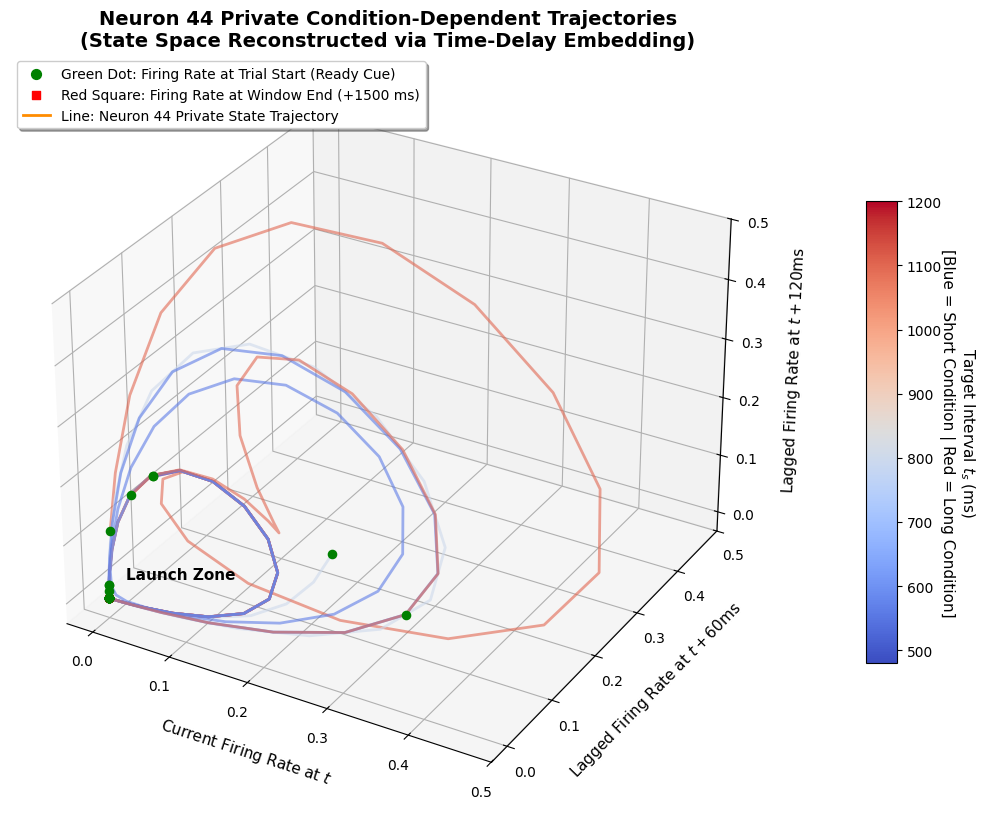

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# 1. Grab task conditions (ts) matching your valid trials exactly
trial_conditions = []
for idx, row in train_trials_df.iterrows():
    if row['is_outlier'] or np.isnan(row['ready_time']):
        continue
    ready_idx = int(row['ready_time'] / 0.02)
    if ready_idx + 75 < train_matrix.shape[0]:
        trial_conditions.append(row['ts'])
trial_conditions = np.array(trial_conditions)

# 2. Extract and smooth only Neuron 44 (The lowest PSD unit)
target_neuron = 44
neuron_44_raw = lfads_input[:, :, target_neuron]

# Using a slightly stronger smooth filter (sigma=2.5) to clear out noise from this low-power unit
neuron_44_smooth = gaussian_filter1d(neuron_44_raw.astype(float), sigma=2.5, axis=1)

# 3. Create 3D Time-Delay Embedding coordinates (t, t+60ms, t+120ms)
lag1, lag2 = 3, 6
coord_x = neuron_44_smooth[:, :-(lag2)]
coord_y = neuron_44_smooth[:, lag1:-(lag2 - lag1)]
coord_z = neuron_44_smooth[:, lag2:]

# 4. Setup the Detailed 3D Plot
fig = plt.figure(figsize=(13, 10))
ax = fig.add_subplot(111, projection='3d')

# 5. Set up continuous color mapping matching your population plot
valid_mask = ~np.isnan(trial_conditions)
min_ts, max_ts = np.min(trial_conditions[valid_mask]), np.max(trial_conditions[valid_mask])
norm = plt.Normalize(vmin=min_ts, vmax=max_ts)
cmap = plt.cm.coolwarm

# 6. Plot the first 40 trials for Neuron 44
for trial_idx in range(40):
    trial_ts = trial_conditions[trial_idx]
    if np.isnan(trial_ts):
        continue
    line_color = cmap(norm(trial_ts))
    
    # Plot individual trial lines
    ax.plot(coord_x[trial_idx, :], coord_y[trial_idx, :], coord_z[trial_idx, :], color=line_color, alpha=0.6, linewidth=2)
    
    # Track the start (Ready Cue) and end states
    ax.scatter(coord_x[trial_idx, 0], coord_y[trial_idx, 0], coord_z[trial_idx, 0], color='green', s=35, zorder=5)
    ax.scatter(coord_x[trial_idx, -1], coord_y[trial_idx, -1], coord_z[trial_idx, -1], color='red', marker='s', s=25, zorder=5)

# 7. Add informative labels and indicators
mean_start = [np.mean(coord_x[:, 0]), np.mean(coord_y[:, 0]), np.mean(coord_z[:, 0])]
ax.text(mean_start[0], mean_start[1], mean_start[2] + 0.01, "Launch Zone", color='black', weight='bold', fontsize=11)

# Fake markers for a clean legend layout
ax.scatter([], [], [], color='green', s=50, label='Green Dot: Firing Rate at Trial Start (Ready Cue)')
ax.scatter([], [], [], color='red', marker='s', s=40, label='Red Square: Firing Rate at Window End (+1500 ms)')
ax.plot([], [], [], color='darkorange', linewidth=2, label=f'Line: Neuron {target_neuron} Private State Trajectory')

ax.set_xlabel('Current Firing Rate at $t$', fontsize=11, labelpad=10)
ax.set_ylabel('Lagged Firing Rate at $t + 60$ms', fontsize=11, labelpad=10)
ax.set_zlabel('Lagged Firing Rate at $t + 120$ms', fontsize=11, labelpad=10)
ax.set_title(f'Neuron {target_neuron} Private Condition-Dependent Trajectories\n(State Space Reconstructed via Time-Delay Embedding)', fontsize=14, weight='bold')
ax.legend(loc="upper left", fontsize=10, frameon=True, shadow=True)

# Add the continuous condition colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, aspect=15, pad=0.1)
cbar.set_label('Target Interval $t_s$ (ms)\n[Blue = Short Condition | Red = Long Condition]', fontsize=11, rotation=270, labelpad=25)

plt.show()

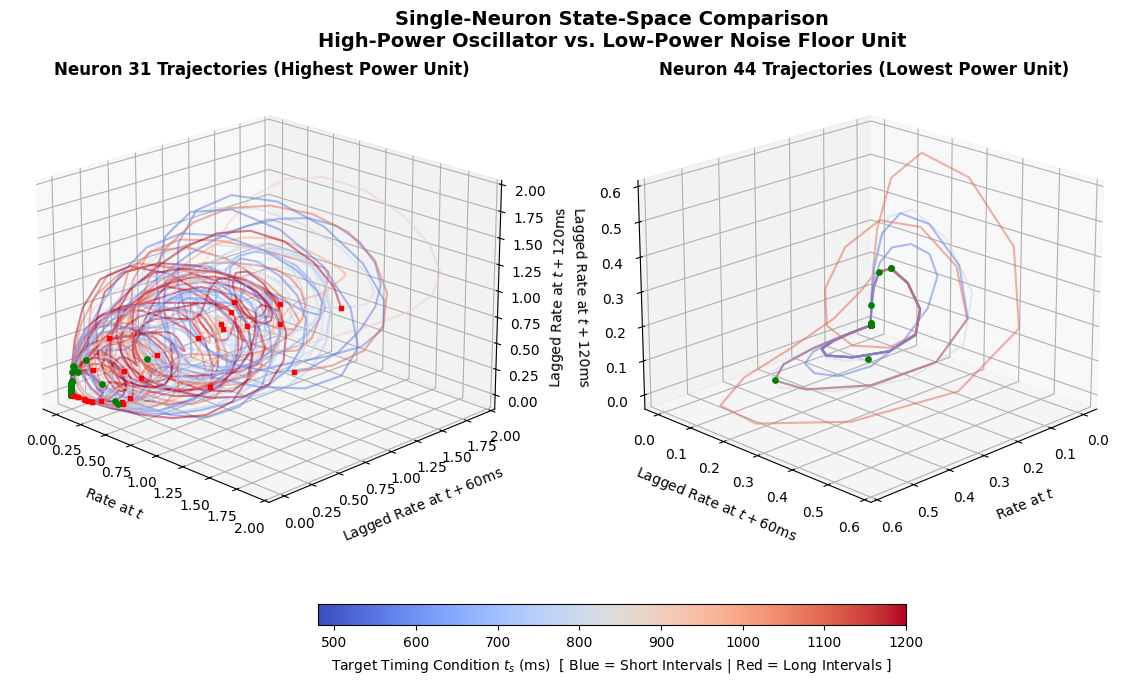

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

trial_conditions = []
for idx, row in train_trials_df.iterrows():
    if row['is_outlier'] or np.isnan(row['ready_time']):
        continue
    ready_idx = int(row['ready_time'] / 0.02)
    if ready_idx + 75 < train_matrix.shape[0]:
        trial_conditions.append(row['ts'])
trial_conditions = np.array(trial_conditions)


n31_raw = lfads_input[:, :, 31]
n31_smooth = gaussian_filter1d(n31_raw.astype(float), sigma=2.0, axis=1)

n44_raw = lfads_input[:, :, 44]
n44_smooth = gaussian_filter1d(n44_raw.astype(float), sigma=2.0, axis=1)


lag1, lag2 = 3, 6

n31_x = n31_smooth[:, :-(lag2)]
n31_y = n31_smooth[:, lag1:-(lag2 - lag1)]
n31_z = n31_smooth[:, lag2:]

n44_x = n44_smooth[:, :-(lag2)]
n44_y = n44_smooth[:, lag1:-(lag2 - lag1)]
n44_z = n44_smooth[:, lag2:]


fig = plt.figure(figsize=(14, 7))
cmap = plt.cm.coolwarm
norm = plt.Normalize(vmin=np.nanmin(trial_conditions), vmax=np.nanmax(trial_conditions))

# Adjusted bounding boxes to give breathing room for labels
box_left  = [0.03, 0.16, 0.44, 0.72]
box_right = [0.46, 0.16, 0.44, 0.72] 

# --- LEFT SUBPLOT: NEURON 31 ---
ax1 = fig.add_axes(box_left, projection='3d')
for i in range(40):
    ts = trial_conditions[i]
    if np.isnan(ts): continue
    ax1.plot(n31_x[i, :], n31_y[i, :], n31_z[i, :], color=cmap(norm(ts)), alpha=0.5, linewidth=1.5)
    ax1.scatter(n31_x[i, 0], n31_y[i, 0], n31_z[i, 0], color='green', s=15, zorder=5)
    ax1.scatter(n31_x[i, -1], n31_y[i, -1], n31_z[i, -1], color='red', marker='s', s=12, zorder=5)

ax1.set_xlabel('Rate at $t$', labelpad=8)
ax1.set_ylabel('Lagged Rate at $t+60$ms', labelpad=8)
ax1.set_zlabel('Lagged Rate at $t+120$ms', labelpad=4)
ax1.set_title('Neuron 31 Trajectories (Highest Power Unit)', fontsize=12, y=1.02, weight='bold')
ax1.view_init(elev=20, azim=-45) # Keep original clean angle


ax2 = fig.add_axes(box_right, projection='3d')
for i in range(40):
    ts = trial_conditions[i]
    if np.isnan(ts): continue
    ax2.plot(n44_x[i, :], n44_y[i, :], n44_z[i, :], color=cmap(norm(ts)), alpha=0.5, linewidth=1.5)
    ax2.scatter(n44_x[i, 0], n44_y[i, 0], n44_z[i, 0], color='green', s=15, zorder=5)
    ax2.scatter(n44_x[i, -1], n44_y[i, -1], n44_z[i, -1], color='red', marker='s', s=12, zorder=5)

ax2.set_xlabel('Rate at $t$', labelpad=8)
ax2.set_ylabel('Lagged Rate at $t+60$ms', labelpad=8)
ax2.set_zlabel('Lagged Rate at $t+120$ms', labelpad=4)
ax2.set_title('Neuron 44 Trajectories (Lowest Power Unit)', fontsize=12, y=1.02, weight='bold')
ax2.view_init(elev=20, azim=45) # CRITICAL FIX: Rotated to 45 to mirror text to the outside left wall!


fig.suptitle('Single-Neuron State-Space Comparison\nHigh-Power Oscillator vs. Low-Power Noise Floor Unit', fontsize=14, weight='bold', y=0.94)

# Centered colorbar placement
cbar_box = [0.29, 0.06, 0.42, 0.03]
cbar_ax = fig.add_axes(cbar_box)
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), cax=cbar_ax, orientation='horizontal')
cbar.set_label('Target Timing Condition $t_s$ (ms)  [ Blue = Short Intervals | Red = Long Intervals ]', fontsize=10, labelpad=5)

plt.show()